In [24]:
with open("The Adventures of Sherlock Holmes.txt", 'r') as text_file:
    text = text_file.read()[1474:] # remove metadata

In [25]:
pre_bpe_vocab_size = len(set(text))

In [26]:
joined = "".join(text)
text_utf_8 = list(joined.encode("utf-8"))
pre_bpe_text_len = len(text_utf_8)
pre_bpe_text_len

593820

# Building token vocab

In [27]:
from collections import Counter
from itertools import pairwise


def get_pair_counter(input_seq):
    return Counter(pairwise(input_seq))

In [28]:
def top_pair(pair_counter):
    return max(pair_counter, key=pair_counter.get)

In [29]:
def replace_pair(input_seq, old_pair, new_elem):
    def _pair(i):
        return (input_seq[i], input_seq[i + 1])

    result = []
    i = 0
    while i < len(input_seq):
        if i < len(input_seq) - 1 and _pair(i) == old_pair:
            result.append(new_elem)
            i += 2
        else:
            result.append(input_seq[i])
            i += 1
    return result

In [30]:
vocab_size = 276

bpe_map: dict[tuple[int, int], int] = {}

bpe_text = list(text_utf_8)

for i in range(256, vocab_size):
    pair_counter = get_pair_counter(bpe_text)
    pair = top_pair(pair_counter)
    bpe_text = replace_pair(bpe_text, pair, i)
    bpe_map[pair] = i

In [31]:
print(f"Original input size: {len(text)}")
print(f"Compressed size: {len(bpe_text)}")
print(f"New vocab size: {vocab_size}")
print(f"Compression ratio: {len(text) / len(bpe_text):.2f}x")

Original input size: 580127
Compressed size: 459843
New vocab size: 276
Compression ratio: 1.26x


In [32]:
vocab = {idx: bytes([idx]) for idx in range(256)}
for (fst, snd), idx in bpe_map.items():
    vocab[idx] = vocab[fst] + vocab[snd]

In [33]:
def encode(input_seq):
    utf = list(input_seq.encode('utf-8'))
    for pair, key in bpe_map.items():
        utf = replace_pair(utf, pair, key)
    return utf

In [34]:
def decode(input_seq):
    tokens = b"".join(vocab[idx] for idx in input_seq)
    return tokens.decode('utf-8', errors='replace')

In [35]:
pre_encode = text[:10000]
pre_encode == decode(encode(pre_encode))

True

# Training GPT from previous section with new vocabulary

In [36]:
CONTEXT_LEN = 256
BATCH_SIZE = 64
EMB_SIZE = 192
NUM_HEADS = 6
NUM_LAYERS = 4

In [37]:
encoded_text = encode(text)

In [38]:
def train_valid_split(x, ratio):
    a = int(ratio * len(x))
    return x[:a], x[a:]

train_set, valid_set = train_valid_split(encoded_text, ratio=0.9)

In [39]:
from enum import StrEnum

import torch

torch.manual_seed(42)

class SetType(StrEnum):
    TRAIN = "train"
    VALID = "valid"

def get_batch(split: SetType, context_len: int, batch_size: int):
    data_set = train_set if split == SetType.TRAIN else valid_set
    max_rand = len(data_set) - context_len - 1
    offsets = torch.randint(max_rand, size=(batch_size, ))
    x = [data_set[offset:offset+context_len] for offset in offsets]
    y = [data_set[offset+1:offset+context_len+1] for offset in offsets]
    return torch.tensor(x), torch.tensor(y)

In [40]:
import torch.nn.functional as F


@torch.no_grad()
def avg_train_valid_loss(model, eval_iters, context_len, batch_size):
    out = {}
    model.eval()
    for split in (SetType.TRAIN, SetType.VALID):
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, context_len, batch_size)
            X = X.to(device=device)
            Y = Y.to(device=device)
            logits = model(X)
            B, T, C = logits.shape
            losses = F.cross_entropy(logits.view(B * T, C), Y.view(B * T))
        out[split] = losses.mean()
    model.train()
    return out

In [41]:
from my_gpt import Model

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = Model(
    vocab_size,
    EMB_SIZE,
    CONTEXT_LEN,
    NUM_HEADS,
    NUM_LAYERS,
).to(device=device)

In [42]:
EPOCHS = 5000
LEARNING_RATE = 3e-4
EVAL_INTERVAL = 500
EVAL_ITERS = 10

optimizer = torch.optim.AdamW(model.parameters(), LEARNING_RATE, weight_decay=0.1)

lossi = []

for epoch in range(EPOCHS):
    X_train, Y_train = get_batch(SetType.TRAIN, CONTEXT_LEN, BATCH_SIZE)
    X_train = X_train.to(device=device)
    Y_train = Y_train.to(device=device)
    logits = model(X_train)
    B, T, C = logits.shape
    loss = F.cross_entropy(logits.view(B * T, C), Y_train.view(B * T))
    lossi.append(loss.item())
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if epoch % EVAL_INTERVAL == 0:
        losses = avg_train_valid_loss(model, EVAL_ITERS, CONTEXT_LEN, BATCH_SIZE)
        clear_line = "\r" + " " * 80 + "\r"
        losses_str = f"train: {losses[SetType.TRAIN].item():.5f}, valid: {losses[SetType.VALID].item():.5f}"
        print(f"{clear_line}{epoch:>23}/{EPOCHS} {losses_str}")
    else:
        max_len = 50
        current_len = int((epoch % EVAL_INTERVAL) / EVAL_INTERVAL * max_len)
        progress = "#" * current_len + "-" * (max_len - current_len)
        print(f"\rCurrent interval {epoch % EVAL_INTERVAL:>6} {progress} {EVAL_INTERVAL}", end="", flush=True)

                      0/5000 train: 5.63402, valid: 5.63425                     
                    500/5000 train: 2.73487, valid: 2.95118                     
                   1000/5000 train: 2.20185, valid: 2.43523                     
                   1500/5000 train: 1.94842, valid: 2.29141                     
                   2000/5000 train: 1.77530, valid: 2.04983                     
                   2500/5000 train: 1.66898, valid: 2.07618                     
                   3000/5000 train: 1.60147, valid: 1.95098                     
                   3500/5000 train: 1.53115, valid: 2.15581                     
                   4000/5000 train: 1.48286, valid: 2.05397                     
                   4500/5000 train: 1.39273, valid: 2.13774                     
Current interval    499 #################################################- 500

In [43]:
torch.save(model.state_dict(), "model_new_vocab.pt")

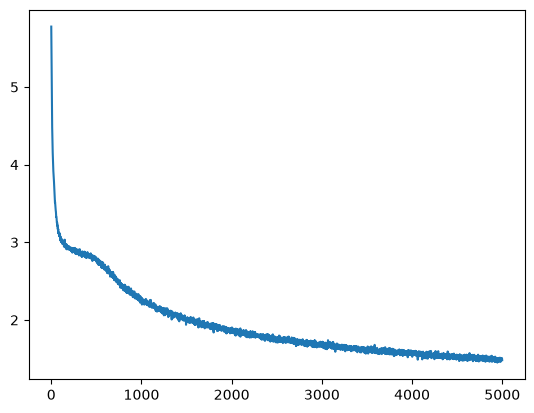

In [44]:
import matplotlib.pyplot as plt

plt.plot(range(EPOCHS), lossi)

In [45]:
def generate(model, idx, max_new_tokens):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -CONTEXT_LEN:]
        logits = model(idx_cond)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [46]:
context = torch.zeros((1, CONTEXT_LEN), dtype=torch.long, device=device)
generated = generate(model, context, max_new_tokens=2000)
print(decode(generated[0, CONTEXT_LEN:].tolist()))

er
fally. Then clumbround in her to longer sudmey. But how’s hang in the floor.

“Ond, how come heary Nonezing, I’ve—he dead,” I sa
reasoned.g Badsaged in one gemnlar and land, that I money, listen by
point.” I have salreman.

There naturally scrayed in the corner everyond, a generation.” Holmes
and gald his well his goldenly. “On, who cab and your swzerbing the letters
things of the extrousers were distent a Fornical. A duk!”

Whattereful you, and I have not hearted the house of him heart, I rushed
to constory Bexpection. Sother braight that it was in a rathy sign
to dle hear and the contrary-ground.”

Abert out off he should said. “Arms the slight,” said he; “but you will not be so say
now, but the careful and parade suggesticulations put overn much a way.

“Thank you, here, a right, and inking?”

“Her business a scepeeding per of use.” He lipped broken out her, and the
boated surprisety; sweet at it was as young of the Cale. Final enty
many moneyes. Mus. How sparted out, it without 